## STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Interpretation:**
* pandas → data handling
* matplotlib → plotting graphs
* seaborn → better visualizations

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Interpretation:**
* We are using the built-in Titanic dataset from seaborn
* Each row represents a passenger
* Columns include: survived, age, sex, class, fare, etc.

## STEP 3: EXPLORATORY DATA ANALYSIS (EDA)

### 3.1 Dataset Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


**Interpretation:**
* Shows:
    * Total rows = 891
    * Data types = int, float, object
* Helps identify:
    * Missing values
    * Categorical vs numerical data

### 3.2 Check Missing Values

In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

**Interpretation:**
* Missing values found in:
    * Age
    * Cabin (many missing)
    * Embarked
* Need cleaning before analysis

### 3.3 Statistical Summary

In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Interpretation:**
* Shows:
    * Mean, min, max, etc.
* Example insights:
    * Average age ~29
    * Fare varies widely → possible outliers

## STEP 4: DATA CLEANING

### 4.1 Handle Missing Values

In [6]:
# Fill Age with median

df['age'] = df['age'].fillna(df['age'].median())

**Interpretation:**
* Median is better than mean (less affected by outliers)
* Null values in Age will be filled with middle value

In [7]:
# Fill Embarked with mode

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

**Interpretation:**
* Mode = most frequent value
* Null values in Embarked will be filled with most frequent value

In [8]:
# Drop Cabin column

df = df.drop(columns=['deck'])

**Interpretation:**
* Too many missing values → not useful

In [9]:
# Fill Embark Town with mode

df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

**Interpretation:**
* We replace missing values in Embark Town with most frequent category

### 4.2 Verify Cleaning

In [10]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

**Interpretation:**
* Now dataset is clean (no missing values)

## STEP 5: EXPLORE RELATIONSHIPS & PATTERNS

### 5.1 Survival Distribution

In [11]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

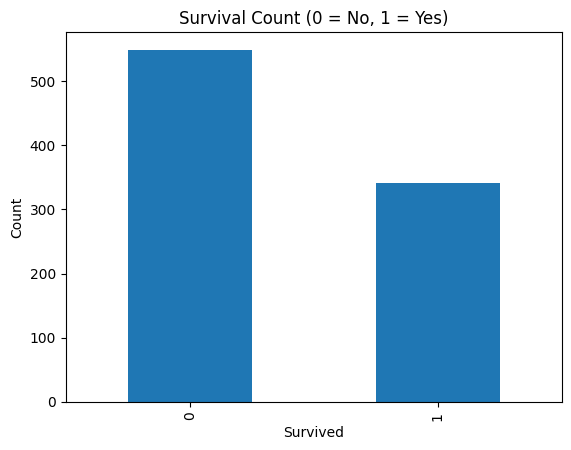

In [12]:
plt.figure()
df['survived'].value_counts().plot(kind='bar')
plt.title("Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

**Interpretation:**
* More people did not survive
* Dataset is imbalanced

### 5.2 Survival by Gender

In [13]:
pd.crosstab(df['sex'], df['survived'])

survived,0,1
sex,,
female,81,233
male,468,109


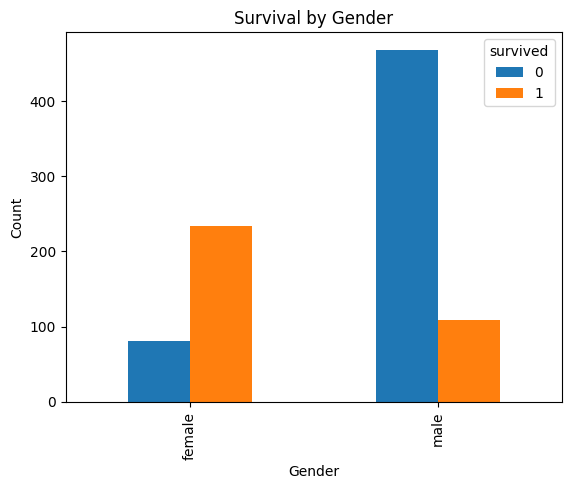

In [14]:
pd.crosstab(df['sex'], df['survived']).plot(kind='bar')
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

**Interpretation:**
* Females had higher survival rate
* “Women and children first” rule observed
* Death of males are more

### 5.3 Age Distribution

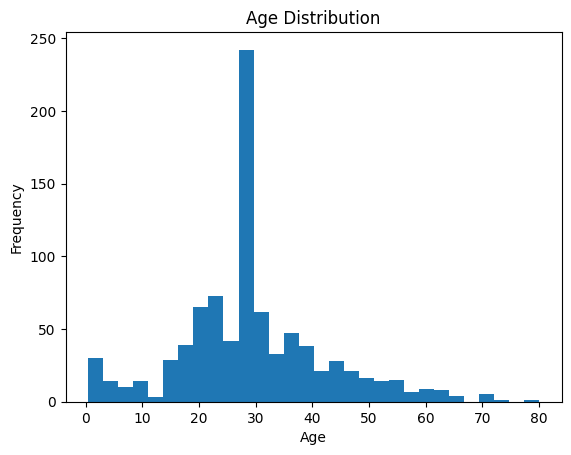

In [15]:
plt.figure()
plt.hist(df['age'], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Interpretation:**
* Most passengers are between 20–40 years
* Few elderly passengers

### 5.4 Survival by Passenger Class

In [16]:
pd.crosstab(df['pclass'], df['survived'])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


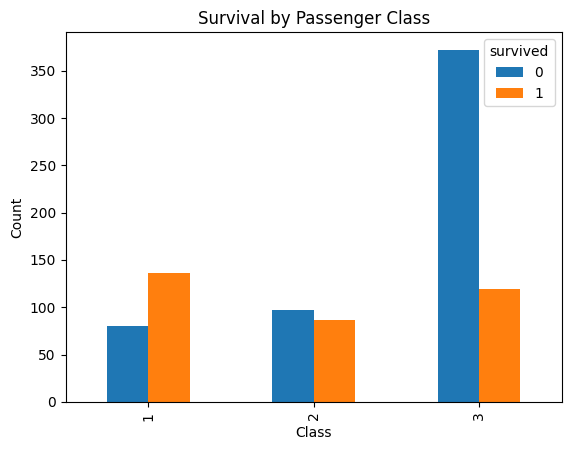

In [17]:
pd.crosstab(df['pclass'], df['survived']).plot(kind='bar')
plt.title("Survival by Passenger Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

**Interpretation:**
* 1st class → highest survival
* 3rd class → lowest survival
* Wealth influenced survival chances

### 5.5 Fare Distribution

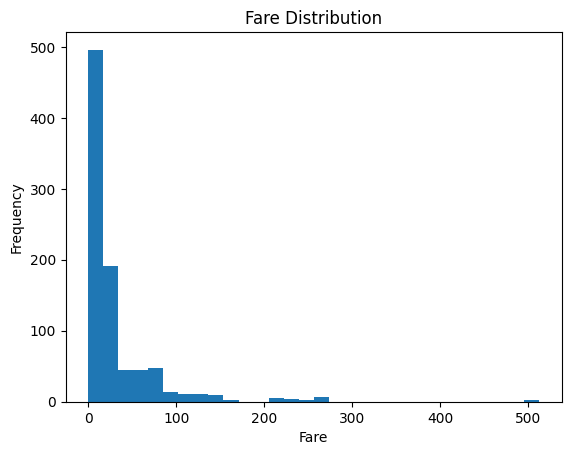

In [18]:
plt.figure()
plt.hist(df['fare'], bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

**Interpretation:**
* Highly right-skewed
* Few passengers paid very high fares